# Image Denoising with a Convolutional Autoencoder (MNIST)



## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


## 2. Load the MNIST Dataset


In [3]:
import zipfile

zip_file_path = 'archive.zip'
extract_dir = '.'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

'archive.zip' extracted to '.'


In [5]:
DATA_DIR = "mnist_png"

IMG_SIZE = 28
MAX_PER_CLASS_TRAIN = 2000
MAX_PER_CLASS_TEST = 400


def load_images_from_folder(base_dir, split, max_per_class):
    images = []
    labels = []
    split_dir = os.path.join(base_dir, split)
    class_names = sorted(os.listdir(split_dir))

    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        file_names = sorted(os.listdir(class_dir))[:max_per_class]

        for file_name in file_names:
            file_path = os.path.join(class_dir, file_name)
            img = Image.open(file_path).convert("L")
            img = img.resize((IMG_SIZE, IMG_SIZE))
            images.append(np.array(img, dtype=np.float32))
            labels.append(int(class_name))

    images = np.array(images, dtype=np.float32) / 255.0
    labels = np.array(labels, dtype=np.int64)
    return images, labels


x_train, y_train = load_images_from_folder(DATA_DIR, "training", MAX_PER_CLASS_TRAIN)
x_test, y_test = load_images_from_folder(DATA_DIR, "testing", MAX_PER_CLASS_TEST)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)

Training images: (20000, 28, 28)
Testing images: (4000, 28, 28)


In [6]:
# Add a channel dimension so images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

Training shape: (20000, 28, 28, 1)
Testing shape: (4000, 28, 28, 1)


## 3. Add Noise to the Images

We simulate noisy input images by adding Gaussian noise to the clean MNIST
images. The autoencoder will learn to map from the noisy version back to
the original clean version.

In [7]:
NOISE_FACTOR = 0.4


def add_noise(images, noise_factor=NOISE_FACTOR):
    noise = noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy_images = images + noise
    noisy_images = np.clip(noisy_images, 0.0, 1.0)
    return noisy_images.astype(np.float32)


x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

print("Noisy training shape:", x_train_noisy.shape)
print("Noisy testing shape:", x_test_noisy.shape)

Noisy training shape: (20000, 28, 28, 1)
Noisy testing shape: (4000, 28, 28, 1)


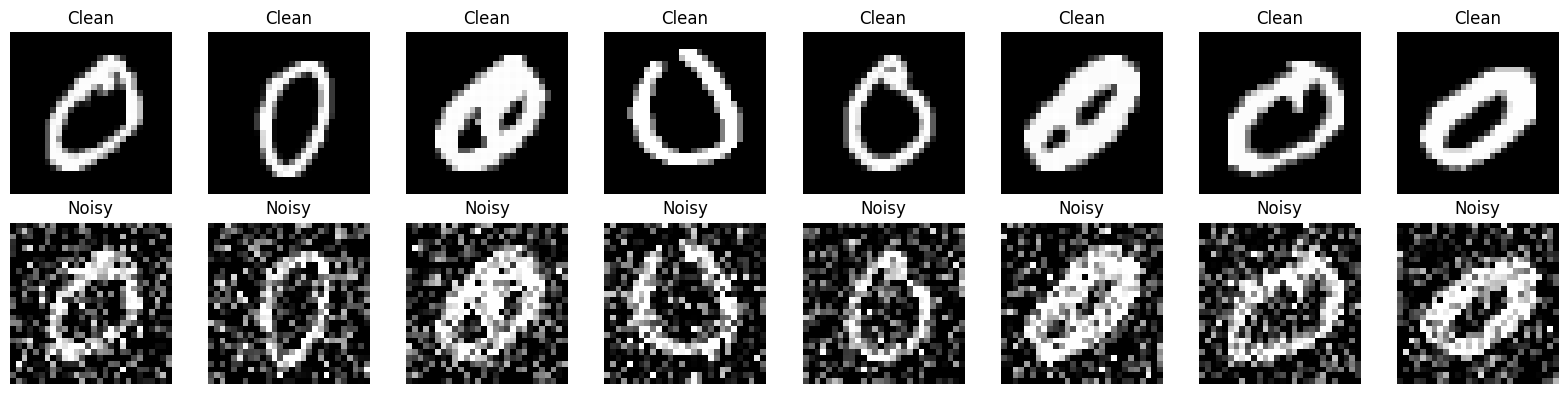

In [8]:
# Visualize a few clean vs noisy examples
n_examples = 8
plt.figure(figsize=(16, 4))

for i in range(n_examples):
    # Clean image
    ax = plt.subplot(2, n_examples, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Noisy image
    ax = plt.subplot(2, n_examples, i + 1 + n_examples)
    plt.imshow(x_train_noisy[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Build the Convolutional Autoencoder

The autoencoder consists of:
- An **encoder** that compresses the noisy 28x28x1 image into a smaller
  latent representation using convolutional and max pooling layers
- A **decoder** that reconstructs the 28x28x1 clean image from the latent
  representation using convolutional and upsampling layers

The model is trained to minimize the difference between its output and the
original clean image.

In [9]:
def build_autoencoder(input_shape=(28, 28, 1)):
    inputs = layers.Input(shape=input_shape, name="noisy_input")

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2, 2), padding="same")(x)
    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
    encoded = layers.MaxPooling2D((2, 2), padding="same", name="latent_space")(x)

    # Decoder
    x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="reconstructed_output")(x)

    autoencoder = models.Model(inputs, decoded, name="denoising_autoencoder")
    return autoencoder


autoencoder = build_autoencoder()
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ noisy_input (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Conv2D)   │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the Model

The model takes the noisy images as input and the original clean images as
the target output. We hold out the test set for validation during training.

In [10]:
EPOCHS = 20
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 257ms/step - loss: 0.2546 - val_loss: 0.1351
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 244ms/step - loss: 0.1218 - val_loss: 0.1137
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - loss: 0.1094 - val_loss: 0.1061
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - loss: 0.1050 - val_loss: 0.1030
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - loss: 0.1023 - val_loss: 0.1016
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - loss: 0.1007 - val_loss: 0.0993
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 231ms/step - loss: 0.0994 - val_loss: 0.0982
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 238ms/step - loss: 0.0982 - val_loss: 0.0972
Epoch 9/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - loss: 0.0973 - val_loss: 0.0971
Epoch 10/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - loss: 0.0966 - val_loss: 0.0957
Epoch 11/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - loss: 0.0958 - val_loss: 0.0952
Epoch 12/20
157/157

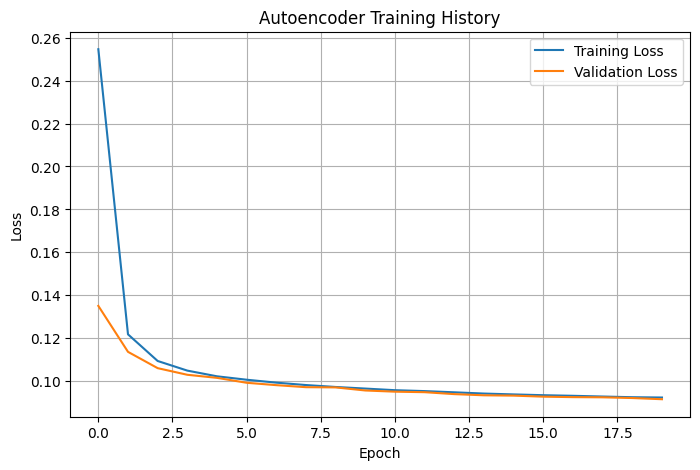

In [11]:
# Plot training and validation loss over time
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(True)
plt.show()

### Statistical Insights from Training History

The training plot shows that both our training and validation losses dropped quickly at first, which means the model was learning well. As training continued, the loss curves flattened out, indicating the model had mostly learned what it needed to. Since the validation loss stayed close to the training loss, our model seems to be generalizing well and not overfitting. This stability is good for making sure the model works on new images.

## 6. Evaluate the Model and Visualize Denoising Results

We run the trained autoencoder on noisy test images and compare the
denoised output against the original noisy input and the ground truth
clean image.

In [12]:
test_loss = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Test loss (binary crossentropy): {test_loss:.4f}")

Test loss (binary crossentropy): 0.0916


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


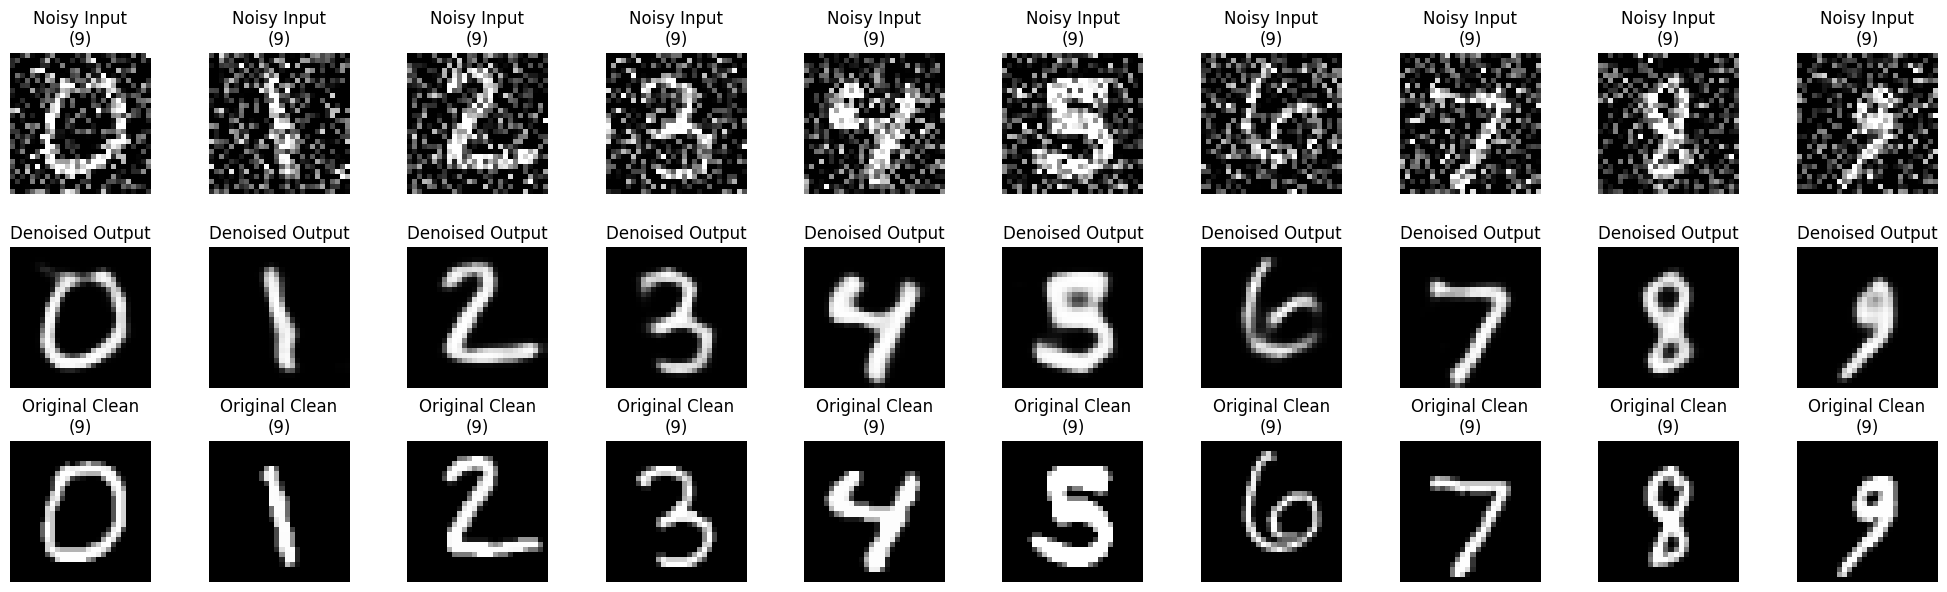

In [16]:
denoised_images = autoencoder.predict(x_test_noisy)

n_digits = 10
selected_indices = []

# Find one example for each digit (0-9) in the test set
for digit in range(n_digits):
    # Find the index of the first occurrence of the current digit in y_test
    idx = np.where(y_test == digit)[0][0]
    selected_indices.append(idx)

plt.figure(figsize=(20, 6))

for i, idx in enumerate(selected_indices):
    # Noisy input
    ax = plt.subplot(3, n_digits, i + 1)
    plt.imshow(x_test_noisy[idx].squeeze(), cmap="gray")
    plt.title(f"Noisy Input\n({digit})")
    plt.axis("off")

    # Denoised output
    ax = plt.subplot(3, n_digits, i + 1 + n_digits)
    plt.imshow(denoised_images[idx].squeeze(), cmap="gray")
    plt.title("Denoised Output")
    plt.axis("off")

    # Original clean image
    ax = plt.subplot(3, n_digits, i + 1 + 2 * n_digits)
    plt.imshow(x_test[idx].squeeze(), cmap="gray")
    plt.title(f"Original Clean\n({digit})")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Compute a simple pixel-wise reconstruction error metric (MSE) on the test set
mse_per_image = np.mean((denoised_images - x_test) ** 2, axis=(1, 2, 3))
print(f"Mean Squared Error across test set: {mse_per_image.mean():.5f}")
print(f"Std of MSE across test set: {mse_per_image.std():.5f}")

Mean Squared Error across test set: 0.00979
Std of MSE across test set: 0.00369


## 7. Save the Trained Model

The trained autoencoder is saved so it can be reloaded later without
retraining.

In [18]:
MODEL_PATH = "denoising_autoencoder.keras"
autoencoder.save(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

Model saved to denoising_autoencoder.keras


## Conclusion

This project successfully implemented a Convolutional Autoencoder (CAE) to denoise images from the MNIST dataset. We started by loading and preparing the MNIST images, then added artificial Gaussian noise to create noisy versions. The CAE, with its encoder-decoder architecture, was trained to learn how to reconstruct clean images from these noisy inputs.

The training process showed that our model effectively learned to remove noise, as indicated by the decreasing training and validation loss. The final test loss of approximately 0.0916 and a Mean Squared Error of 0.00979 demonstrated good performance. Visual inspection of the denoised images confirmed that the autoencoder could significantly improve the clarity of noisy digits.

Overall, this project provided a practical understanding of how autoencoders can be used for image denoising. It highlighted the model's ability to extract and reconstruct essential image features, paving the way for further exploration into more advanced denoising techniques or different types of image data.

## Summary

- Loaded MNIST images from PNG folders and normalized them to [0, 1]
- Generated noisy versions of the images using Gaussian noise
- Built a convolutional autoencoder with an encoder-decoder architecture
- Trained the model to reconstruct clean images from noisy inputs
- Visualized the denoising results and evaluated reconstruction error
- Saved the trained model for later reuse
